In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Creation of data frame
df = pd.read_csv(r"C:\Users\happy\Documents\DSP LAB\Customer\Customer Purchasing Behaviors.csv")

In [5]:
df.head()

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13


In [6]:
df.tail()

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
233,234,40,60000,450,7.2,West,20
234,235,38,59000,430,6.9,North,20
235,236,54,74000,630,9.4,South,27
236,237,32,52000,360,5.8,West,18
237,238,31,51000,340,5.6,North,17


In [8]:
#to know the how many rows and column exists
df.shape #(rows,column)

(238, 7)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             238 non-null    int64  
 1   age                 238 non-null    int64  
 2   annual_income       238 non-null    int64  
 3   purchase_amount     238 non-null    int64  
 4   loyalty_score       238 non-null    float64
 5   region              238 non-null    object 
 6   purchase_frequency  238 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 13.1+ KB


In [10]:
df.columns # to know the column names

Index(['user_id', 'age', 'annual_income', 'purchase_amount', 'loyalty_score',
       'region', 'purchase_frequency'],
      dtype='object')

In [81]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
233    False
234    False
235    False
236    False
237    False
Length: 238, dtype: bool

In [82]:
df.duplicated().sum()  #to get the count

np.int64(0)

In [14]:
df.sample(5)

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
134,135,52,72000,610,9.2,West,26
227,228,50,70000,600,9.0,West,25
64,65,43,63000,470,7.8,South,21
216,217,50,70000,600,9.0,North,25
81,82,26,44000,240,4.3,North,14


In [15]:
df.dtypes


user_id                 int64
age                     int64
annual_income           int64
purchase_amount         int64
loyalty_score         float64
region                 object
purchase_frequency      int64
dtype: object

In [18]:
df.isnull().sum() #if sum() is not used we will get total dataframe with true-null means and false-if not null

user_id               0
age                   0
annual_income         0
purchase_amount       0
loyalty_score         0
region                0
purchase_frequency    0
dtype: int64

In [19]:
(df.isnull().sum() / len(df)) * 100

user_id               0.0
age                   0.0
annual_income         0.0
purchase_amount       0.0
loyalty_score         0.0
region                0.0
purchase_frequency    0.0
dtype: float64

In [20]:
len(df)

238

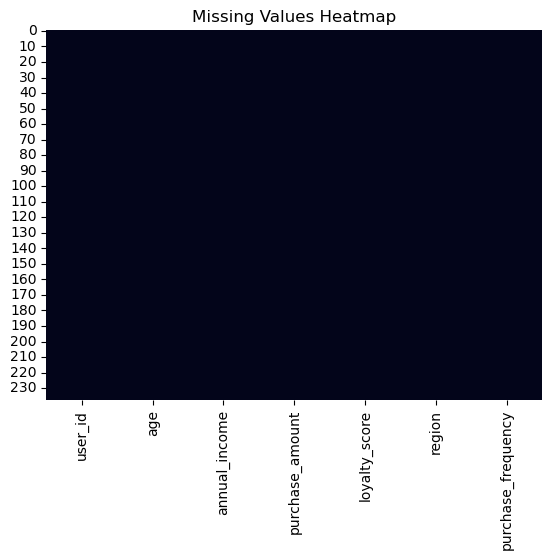

In [29]:
sns.heatmap(df.isnull(), cbar=False, cmap="rocket") 
plt.title("Missing Values Heatmap")
plt.show()
# Cmap Name	Visual Style
# "magma"	High contrast; dark purple to bright orange.
# "plasma"	Vibrant; purple to pink to yellow.
# "rocket"	Deep red to pale cream (very popular in Seaborn).
# "mako"	Deep blues to pale greens.
# "Greys"	Simple black and white (great for printing).
# "coolwarm"	Blue for one state, red for the other.

In [42]:
df.describe(include="all")


,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
count,238.000000,238.000000,238.000000,238.000000,238.000000,238,238.000000
unique,NaN,NaN,NaN,NaN,NaN,4,NaN
top,NaN,NaN,NaN,NaN,NaN,North,NaN
freq,NaN,NaN,NaN,NaN,NaN,78,NaN
mean,119.500000,38.676471,57407.563025,425.630252,6.794118,NaN,19.798319
std,68.848868,9.351118,11403.875717,140.052062,1.899047,NaN,4.562884
min,1.000000,22.000000,30000.000000,150.000000,3.000000,NaN,10.000000
25%,60.250000,31.000000,50000.000000,320.000000,5.500000,NaN,17.000000
50%,119.500000,39.000000,59000.000000,440.000000,7.000000,NaN,20.000000
75%,178.750000,46.750000,66750.000000,527.500000,8.275000,NaN,23.000000


In [25]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns


In [31]:
#filling the null with mean()
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

In [33]:
#filling the mull with the median()
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [35]:
#filling the null with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [43]:
df.to_csv("cleaned_customer_data.csv", index=False)


In [44]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
num_cols


Index(['user_id', 'age', 'annual_income', 'purchase_amount', 'loyalty_score',
       'purchase_frequency'],
      dtype='object')

In [45]:
df[num_cols].mean()

user_id                 119.500000
age                      38.676471
annual_income         57407.563025
purchase_amount         425.630252
loyalty_score             6.794118
purchase_frequency       19.798319
dtype: float64

In [46]:
df[num_cols].median()


user_id                 119.5
age                      39.0
annual_income         59000.0
purchase_amount         440.0
loyalty_score             7.0
purchase_frequency       20.0
dtype: float64

In [47]:
df[num_cols].mode()


,user_id,age,annual_income,purchase_amount,loyalty_score,purchase_frequency
0,1,24.0,32000.0,600.0,9.0,21.0
1,2,33.0,46000.0,NaN,NaN,NaN
2,3,41.0,53000.0,NaN,NaN,NaN
3,4,50.0,61000.0,NaN,NaN,NaN
4,5,NaN,70000.0,NaN,NaN,NaN
...,...,...,...,...,...,...
233,234,NaN,NaN,NaN,NaN,NaN
234,235,NaN,NaN,NaN,NaN,NaN
235,236,NaN,NaN,NaN,NaN,NaN
236,237,NaN,NaN,NaN,NaN,NaN


In [49]:
df[num_cols].std()


user_id                  68.848868
age                       9.351118
annual_income         11403.875717
purchase_amount         140.052062
loyalty_score             1.899047
purchase_frequency        4.562884
dtype: float64

In [50]:
df[num_cols].var()


user_id               4.740167e+03
age                   8.744341e+01
annual_income         1.300484e+08
purchase_amount       1.961458e+04
loyalty_score         3.606379e+00
purchase_frequency    2.081991e+01
dtype: float64

In [52]:
df[num_cols].min()

user_id                   1.0
age                      22.0
annual_income         30000.0
purchase_amount         150.0
loyalty_score             3.0
purchase_frequency       10.0
dtype: float64

In [53]:
df[num_cols].max()

user_id                 238.0
age                      55.0
annual_income         75000.0
purchase_amount         640.0
loyalty_score             9.5
purchase_frequency       28.0
dtype: float64

In [54]:
df[num_cols].quantile([0.25, 0.5, 0.75])

,user_id,age,annual_income,purchase_amount,loyalty_score,purchase_frequency
0.25,60.25,31.00,50000.0,320.0,5.500,17.0
0.50,119.50,39.00,59000.0,440.0,7.000,20.0
0.75,178.75,46.75,66750.0,527.5,8.275,23.0


In [55]:
df[num_cols].describe()

,user_id,age,annual_income,purchase_amount,loyalty_score,purchase_frequency
count,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000
mean,119.500000,38.676471,57407.563025,425.630252,6.794118,19.798319
std,68.848868,9.351118,11403.875717,140.052062,1.899047,4.562884
min,1.000000,22.000000,30000.000000,150.000000,3.000000,10.000000
25%,60.250000,31.000000,50000.000000,320.000000,5.500000,17.000000
50%,119.500000,39.000000,59000.000000,440.000000,7.000000,20.000000
75%,178.750000,46.750000,66750.000000,527.500000,8.275000,23.000000
max,238.000000,55.000000,75000.000000,640.000000,9.500000,28.000000


In [57]:
df[num_cols].skew()


user_id               0.000000
age                   0.066784
annual_income        -0.494132
purchase_amount      -0.242574
loyalty_score        -0.345270
purchase_frequency   -0.237064
dtype: float64

In [58]:
df.describe(include="object")


,region
count,238
unique,4
top,North
freq,78


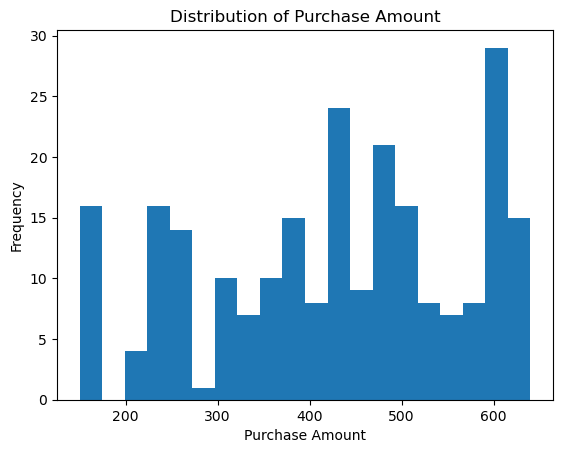

In [77]:
#purchage amount
plt.figure()
plt.hist(df["purchase_amount"], bins=20)
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Purchase Amount")
plt.show()


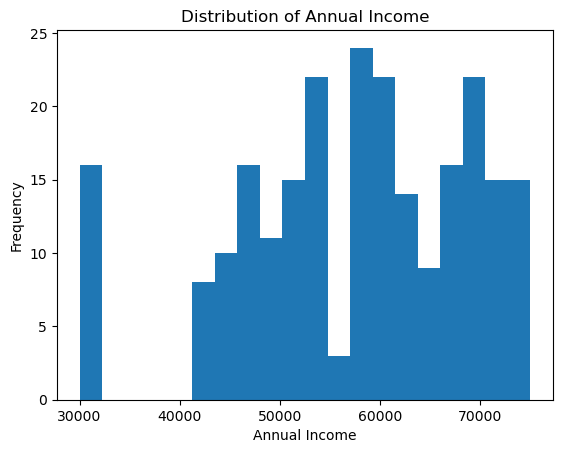

In [65]:
#annual_income
plt.figure()
plt.hist(df["annual_income"], bins=20)
plt.xlabel("Annual Income")
plt.ylabel("Frequency")
plt.title("Distribution of Annual Income")
plt.show()


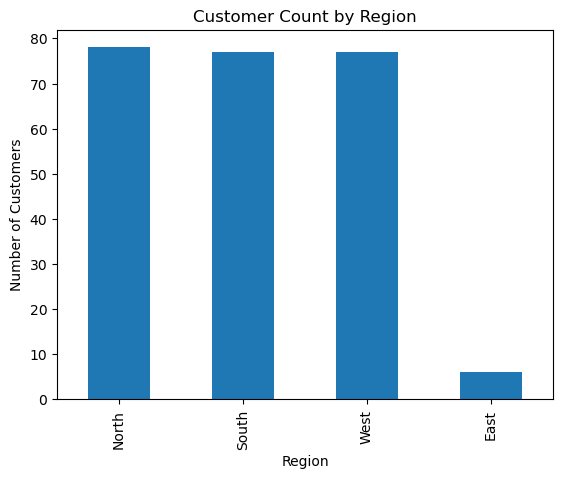

In [68]:
#Customers by Region
plt.figure()
df["region"].value_counts().plot(kind="bar")
plt.xlabel("Region")
plt.ylabel("Number of Customers")
plt.title("Customer Count by Region")
plt.show()


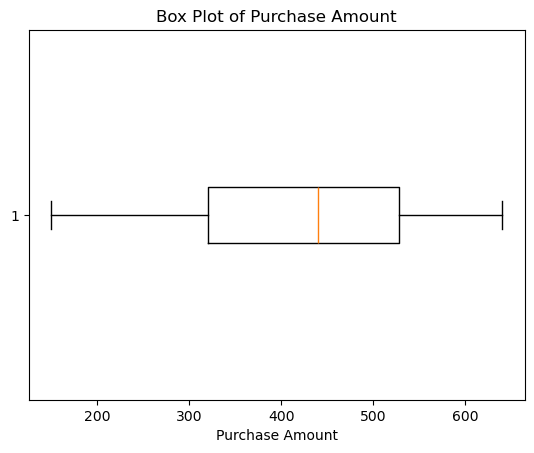

In [79]:
plt.figure()
plt.boxplot(df["purchase_amount"], vert=False)
plt.xlabel("Purchase Amount")
plt.title("Box Plot of Purchase Amount")
plt.show()


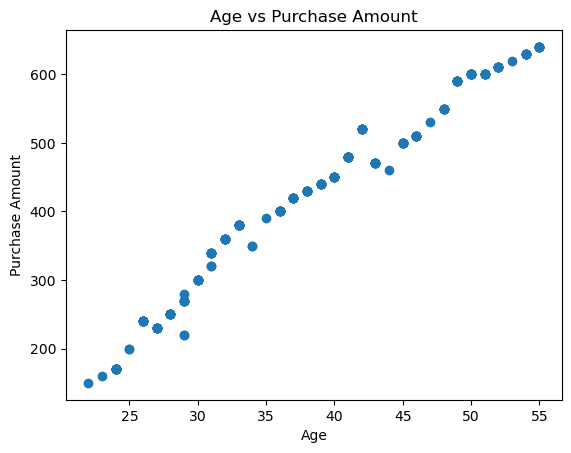

In [70]:
plt.figure()
plt.scatter(df["age"], df["purchase_amount"])
plt.xlabel("Age")
plt.ylabel("Purchase Amount")
plt.title("Age vs Purchase Amount")
plt.show()


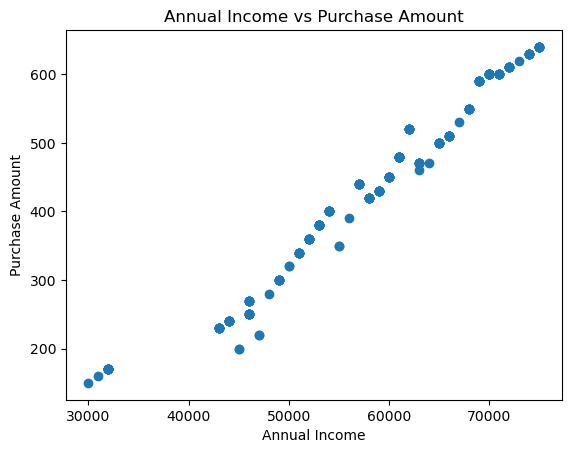

In [71]:
plt.figure()
plt.scatter(df["annual_income"], df["purchase_amount"])
plt.xlabel("Annual Income")
plt.ylabel("Purchase Amount")
plt.title("Annual Income vs Purchase Amount")
plt.show()


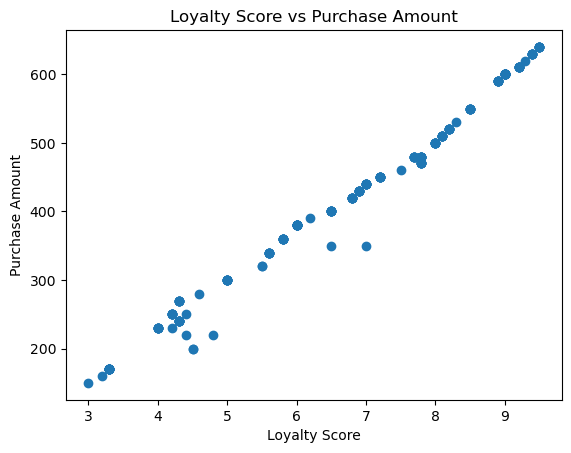

In [72]:
plt.figure()
plt.scatter(df["loyalty_score"], df["purchase_amount"])
plt.xlabel("Loyalty Score")
plt.ylabel("Purchase Amount")
plt.title("Loyalty Score vs Purchase Amount")
plt.show()


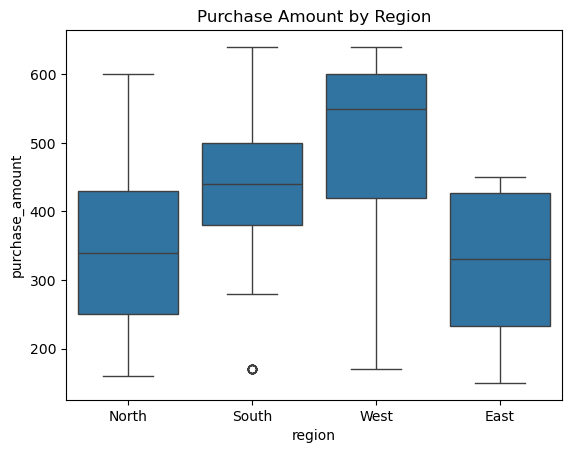

In [73]:
plt.figure()
sns.boxplot(x="region", y="purchase_amount", data=df)
plt.title("Purchase Amount by Region")
plt.show()


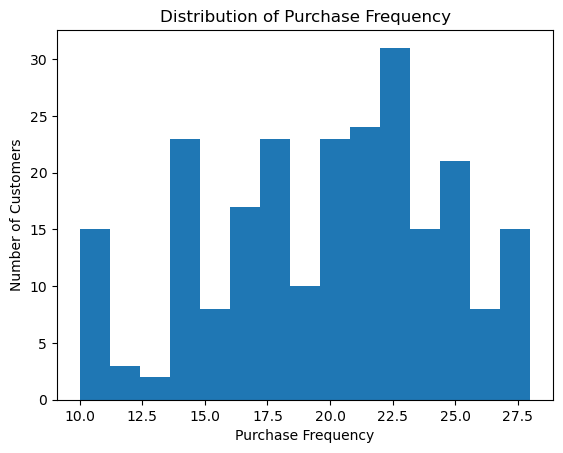

In [74]:
plt.figure()
plt.hist(df["purchase_frequency"], bins=15)
plt.xlabel("Purchase Frequency")
plt.ylabel("Number of Customers")
plt.title("Distribution of Purchase Frequency")
plt.show()


In [75]:
corr = df[[
    "age",
    "annual_income",
    "purchase_amount",
    "loyalty_score",
    "purchase_frequency"
]].corr()
corr


,age,annual_income,purchase_amount,loyalty_score,purchase_frequency
age,1.000000,0.974833,0.986140,0.981835,0.980532
annual_income,0.974833,1.000000,0.984208,0.984351,0.982920
purchase_amount,0.986140,0.984208,1.000000,0.994147,0.993579
loyalty_score,0.981835,0.984351,0.994147,1.000000,0.986990
purchase_frequency,0.980532,0.982920,0.993579,0.986990,1.000000


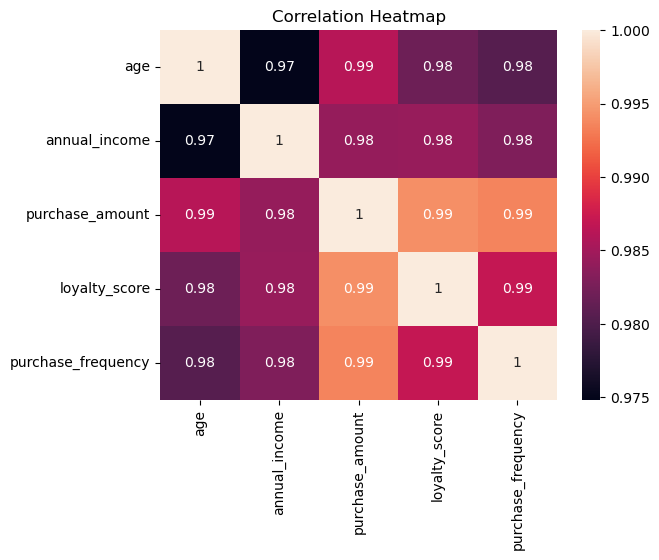

In [76]:
plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()
